<a href="https://colab.research.google.com/github/niruinso/Course_Work/blob/develop/src/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings

warnings.filterwarnings('ignore')

## Загрузим данные.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/StudentPerformanceFactors.csv")
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


## Предлагаю немного изучить наши данные

In [ ]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## Итак, взглянем для начала на численные данные. Мы можем увидеть, что 7 признаков из 20 относятся к численным (конечно же, с учетом экзаминационного результата). Нашим целевым признаком будет Exam_Score. Среди признаков видим количество часов обучения, посещение, количество часов сна, прежние результаты (экзамен за прошлый семестр/год), занятия с репетитором и физическая активность.  Предположительно, признак Previous_Scores будет решающим при определении целевого признака, однако это лишь предположение. Так же интерес выказывает тот факт, что максимальное значение целевого признака - 101 (чего быть не может).

In [ ]:
df.drop(df[df["Exam_Score"] == 101].index, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6606 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6606 non-null   int64 
 1   Attendance                  6606 non-null   int64 
 2   Parental_Involvement        6606 non-null   object
 3   Access_to_Resources         6606 non-null   object
 4   Extracurricular_Activities  6606 non-null   object
 5   Sleep_Hours                 6606 non-null   int64 
 6   Previous_Scores             6606 non-null   int64 
 7   Motivation_Level            6606 non-null   object
 8   Internet_Access             6606 non-null   object
 9   Tutoring_Sessions           6606 non-null   int64 
 10  Family_Income               6606 non-null   object
 11  Teacher_Quality             6528 non-null   object
 12  School_Type                 6606 non-null   object
 13  Peer_Influence              6606 non-null   object
 1

## Видно, что в данных есть отсутствующие значения в некоторых столбцах. К нашим семи численным признакам добавляется 13 признаков типа object: вовлечение родителей, доступ к ресурсам, внеклассные активности, уровень мотивации, доступ к интернету, доход в семье, качество преподавания, тип школы, влияние сверстников, ограниченные возможности обучения, уровень образования родителей, расстояние от дома и пол. Данные и вправду охватывают довольно широкий спектр информации о студенте, и данные выглядят довольно хорошими. Но давайте чуть углубимся в них

In [ ]:
for column in df.columns:
    if(df[column].dtype == 'O'):
        print(f"Feature: {column}, Elements: {df[column].unique()}")

Feature: Parental_Involvement, Elements: ['Low' 'Medium' 'High']
Feature: Access_to_Resources, Elements: ['High' 'Medium' 'Low']
Feature: Extracurricular_Activities, Elements: ['No' 'Yes']
Feature: Motivation_Level, Elements: ['Low' 'Medium' 'High']
Feature: Internet_Access, Elements: ['Yes' 'No']
Feature: Family_Income, Elements: ['Low' 'Medium' 'High']
Feature: Teacher_Quality, Elements: ['Medium' 'High' 'Low' nan]
Feature: School_Type, Elements: ['Public' 'Private']
Feature: Peer_Influence, Elements: ['Positive' 'Negative' 'Neutral']
Feature: Learning_Disabilities, Elements: ['No' 'Yes']
Feature: Parental_Education_Level, Elements: ['High School' 'College' 'Postgraduate' nan]
Feature: Distance_from_Home, Elements: ['Near' 'Moderate' 'Far' nan]
Feature: Gender, Elements: ['Male' 'Female']


## Нетрудно заметить, что некоторые признаки можно легко закодировать без (теоретической) угрозы, что наши модели могут увидеть ненужные паттерны и переобучиться (Low < Medium < High, к примеру). Однако есть и такие категориальные признаки, к которым трудно подобрать такие численные значения без риска переобучения. Для этих (трех) признаков применим OneHotEncoder, который создаёт новые признаки в количестве уникальных значений старого признака и ставит единицу в столбец с встречающимся у объекта значением.

## Создадим класс MyEncoder, который наследуется от BaseEstimator и TransformerMixin. В случае чего данный класс можно будет использовать для пайплайнов, он в функционале основных методов будет схож с реализациями шифраторов от библиотеки sklearn. Основная задача этого класса - просто менять в определенных признаках категориальные значения на численные (согласно теории, что мы можем в некоторых столбцах, исходя из наших данных, сделать это без явной угрозы переобучения).

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class MyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.column_mappings_ = {}
        self.feature_names_in_ = None
        self.n_features_in_ = None


        self.pattern_mappings = {
            frozenset(['Low', 'Medium', 'High']): {'Low': 0, 'Medium': 1, 'High': 2},
            frozenset(['No', 'Yes']): {'No': 0, 'Yes': 1},
            frozenset(['Near', 'Moderate', 'Far']): {'Near': 0, 'Moderate': 1, 'Far': 2},
            frozenset(['Negative', 'Neutral', 'Positive']): {'Negative': -1, 'Neutral': 0, 'Positive': 1},
        }

    def fit(self, X, y=None):
        self.feature_names_in_ = list(X.columns)
        self.n_features_in_ = len(self.feature_names_in_)

        for col in self.feature_names_in_:
            unique_vals = X[col].dropna().unique()
            unique_set = frozenset(unique_vals)

            for pattern, mapping in self.pattern_mappings.items():
                if unique_set.issubset(pattern):
                    self.column_mappings_[col] = mapping
                    break

        return self

    def transform(self, X):
        X_copy = X.copy()

        for col, mapping in self.column_mappings_.items():
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].map(lambda x: mapping.get(x, x) if pd.notna(x) else x)

                X_copy[col] = pd.to_numeric(X_copy[col], errors='coerce')
        return X_copy

    def get_feature_names_out(self):
        return np.array(self.feature_names_in_, dtype=object)

## Создадим также класс DataFrameTransformer, который будет применять к нашим данным созданный ранее шифратор, KNNImputer (заполняет пропущенные значения в зависимости от n ближайших соседей, где n - передаваемый параметр. Ближайший сосед - это объект, расстояние до которого от нашего объекта наименьшее (к примеру, можно использовать евклидову норму))для заполнения пропущенных значений в числовых признаках и SimpleImputer (заполняет константным значением 'missing') для заполнения пропущенных соседей в категориальных признаках.

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer

class DataFrameTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ordinal_encoder =  MyEncoder()
        self.numerical_imputer = KNNImputer(n_neighbors=2, weights="uniform")
        self.categorical_imputer = SimpleImputer(strategy='constant', fill_value='missing')

        self.numerical_cols = None
        self.categorical_cols = None
        self.feature_names = None

    def fit(self, X, y=None):

        self.ordinal_encoder.fit(X)
        X_encoded = self.ordinal_encoder.transform(X)

        self.numerical_cols = X_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
        self.categorical_cols = X_encoded.select_dtypes(include=['object']).columns.tolist()

        self.numerical_imputer.fit(X_encoded[self.numerical_cols])
        self.categorical_imputer.fit(X_encoded[self.categorical_cols])
        self.feature_names = X.columns.tolist()
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_encoded = self.ordinal_encoder.transform(X_copy)

        X_encoded[self.numerical_cols] = self.numerical_imputer.transform(X_encoded[self.numerical_cols])
        X_encoded[self.categorical_cols] = self.categorical_imputer.transform(X_encoded[self.categorical_cols])

        return X_encoded

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names, dtype=object)

## Соберем все в одну функцию для легкой интеграции. Функция будет применять изменения класса DataFrameTransformer(), а после этого для остальных категориальных признаков применять OneHotEncoder()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

class PreprocessingClass(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.transformer =  DataFrameTransformer()
        self.ohe_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

        self.cols_for_ohe = None
        self.feature_names = None

    def fit(self, X, y=None):

        self.transformer.fit(X)
        X_encoded = self.transformer.transform(X)

        self.cols_for_ohe = X_encoded.select_dtypes(include=['object']).columns.tolist()

        self.ohe_encoder.fit(X_encoded[self.cols_for_ohe])
        self.ohe_feature_names = self.ohe_encoder.get_feature_names_out(self.cols_for_ohe).tolist()
        self.feature_names = X_encoded.drop(self.cols_for_ohe, axis=1).columns.tolist() + self.ohe_feature_names
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_transformed = self.transformer.transform(X_copy)

        X_encoded = self.ohe_encoder.transform(X_transformed[self.cols_for_ohe])
        X_encoded_df = pd.DataFrame(X_encoded, columns=self.ohe_encoder.get_feature_names_out())

        return pd.concat([X_transformed.drop(self.cols_for_ohe, axis=1).reset_index(drop=True), X_encoded_df.reset_index(drop=True)], axis=1)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names, dtype=object)

## Нет большого смысла применять изменения для целевого признака. Давайте разделим данные на две части - на целевую и нецелевую части. Для нецелевых признаков применим наши преобразования.

In [ ]:
X = df.drop('Exam_Score', axis=1).reset_index(drop=True)
y = df['Exam_Score'].reset_index(drop=True)

In [ ]:
preprocessing = PreprocessingClass()
X_final = preprocessing.fit_transform(X)
X_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6606 entries, 0 to 6605
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Hours_Studied                          6606 non-null   float64
 1   Attendance                             6606 non-null   float64
 2   Parental_Involvement                   6606 non-null   float64
 3   Access_to_Resources                    6606 non-null   float64
 4   Extracurricular_Activities             6606 non-null   float64
 5   Sleep_Hours                            6606 non-null   float64
 6   Previous_Scores                        6606 non-null   float64
 7   Motivation_Level                       6606 non-null   float64
 8   Internet_Access                        6606 non-null   float64
 9   Tutoring_Sessions                      6606 non-null   float64
 10  Family_Income                          6606 non-null   float64
 11  Teac

## Итак, мы избавились от всех пропущенных значений и категориальных признаков.

In [ ]:
df_experimential = pd.concat([X_final, y], axis=1)
df_experimential

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Distance_from_Home,School_Type_Private,School_Type_Public,Parental_Education_Level_College,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Parental_Education_Level_missing,Gender_Female,Gender_Male,Exam_Score
0,23.0,84.0,0.0,2.0,0.0,7.0,73.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,67
1,19.0,64.0,0.0,1.0,0.0,8.0,59.0,0.0,1.0,2.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,61
2,24.0,98.0,1.0,1.0,1.0,7.0,91.0,1.0,1.0,2.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,74
3,29.0,89.0,0.0,1.0,1.0,8.0,98.0,1.0,1.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,71
4,19.0,92.0,1.0,1.0,1.0,6.0,65.0,1.0,1.0,3.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6601,25.0,69.0,2.0,1.0,0.0,7.0,76.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,68
6602,23.0,76.0,2.0,1.0,0.0,8.0,81.0,1.0,1.0,3.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,69
6603,20.0,90.0,1.0,0.0,1.0,6.0,65.0,0.0,1.0,3.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,68
6604,10.0,86.0,2.0,2.0,1.0,6.0,91.0,2.0,1.0,2.0,...,2.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,68


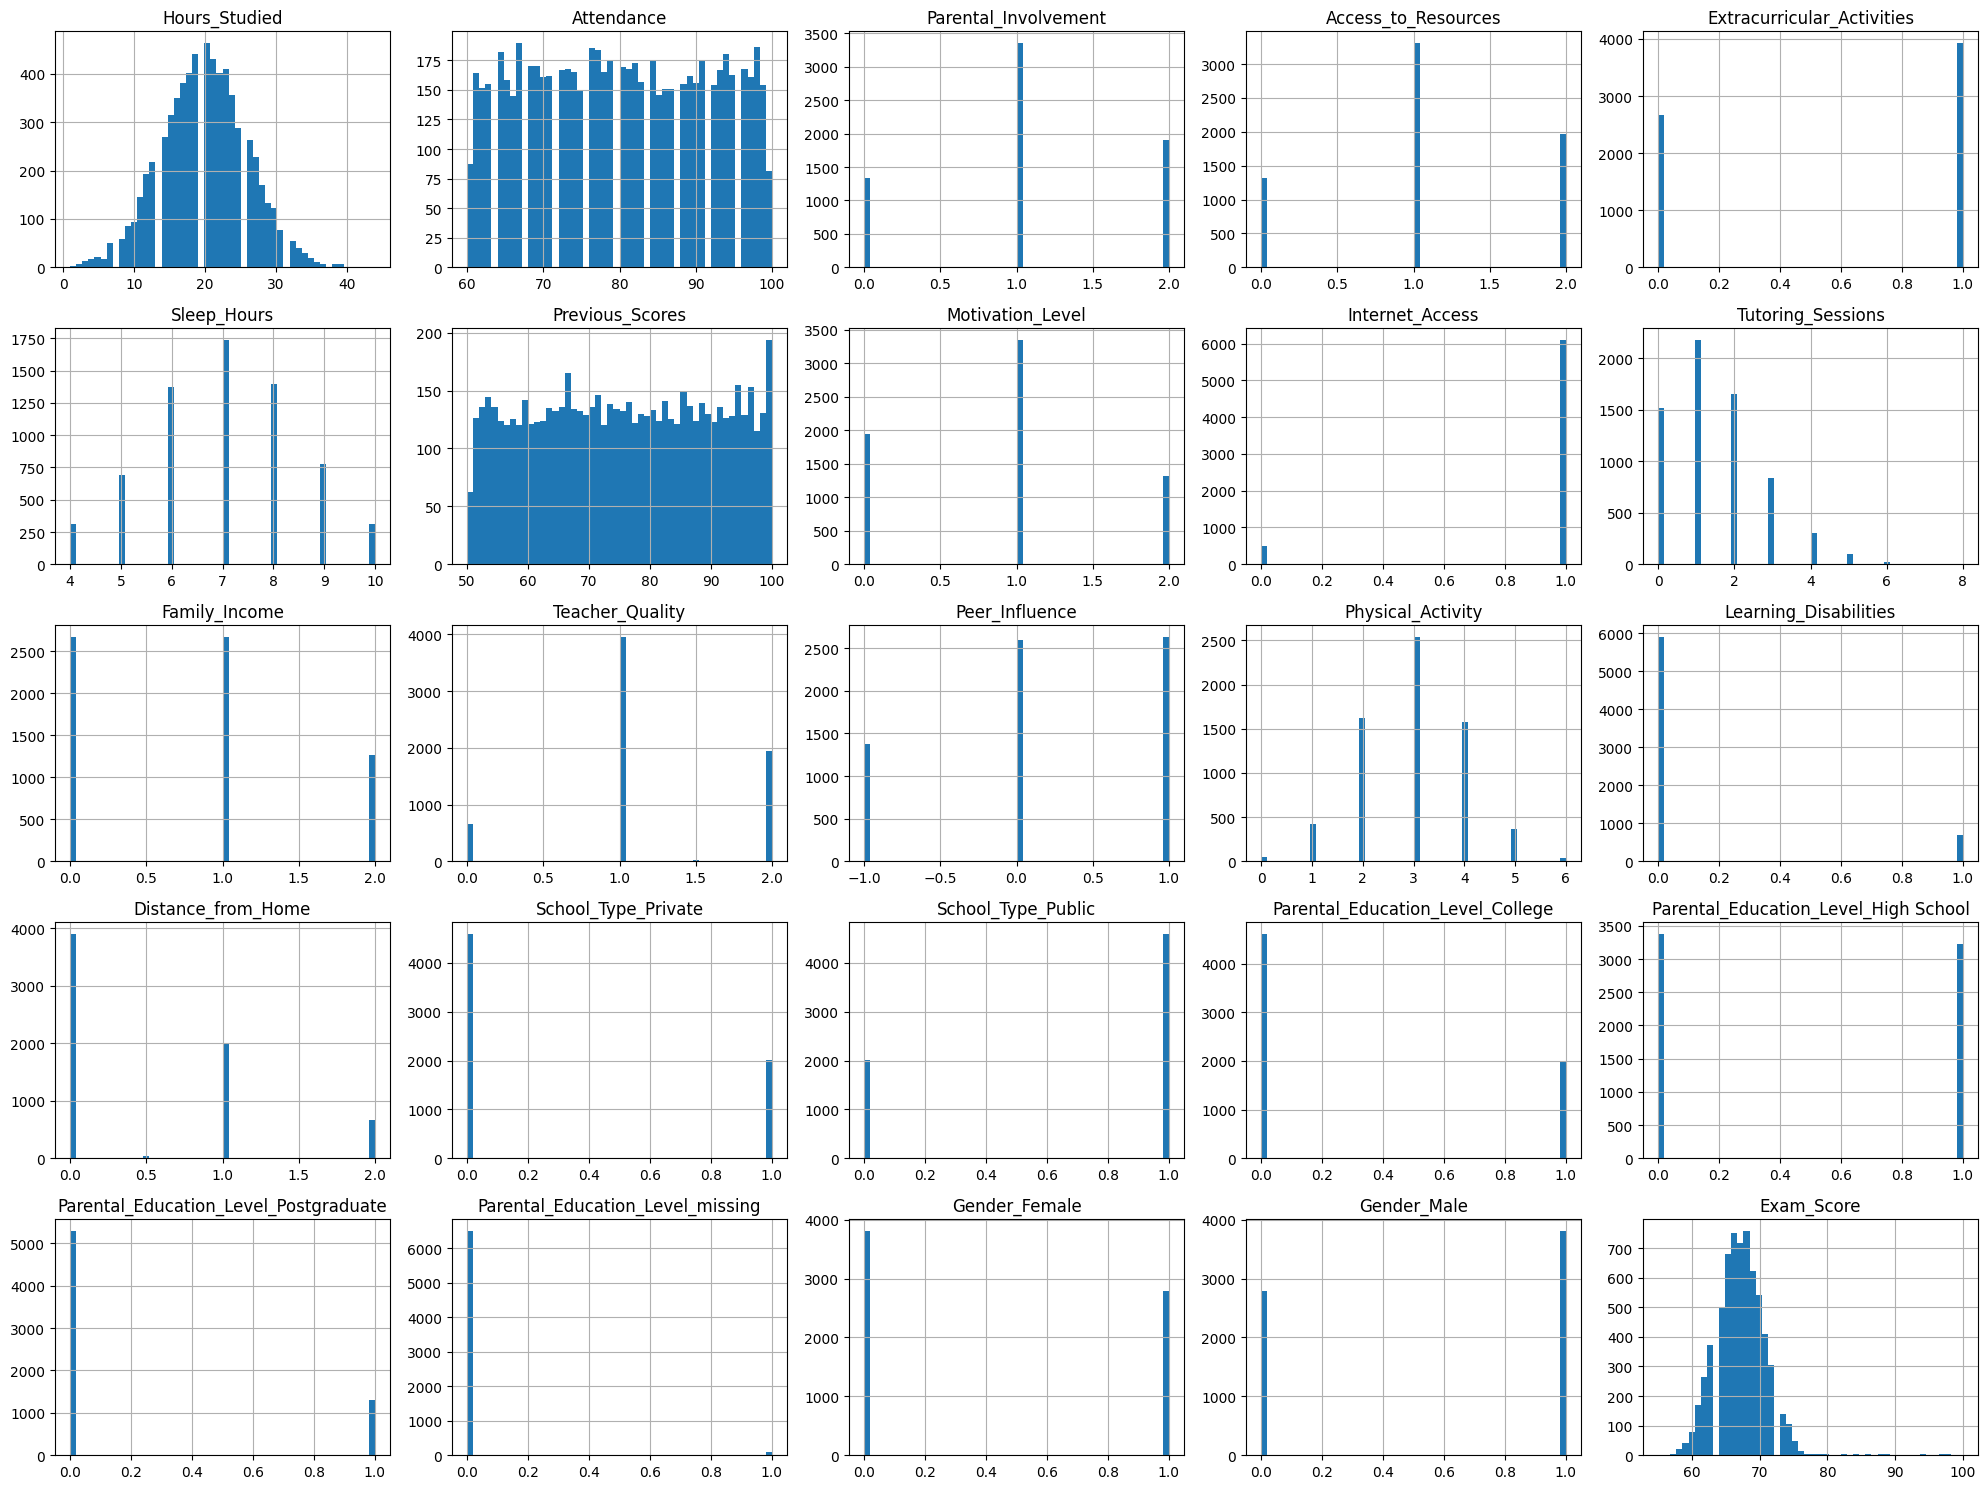

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

df_experimential.hist(bins=50, figsize=(20, 15))
plt.tight_layout()

## Подметим одну интересную деталь: понижение результата за нынешний экзамен по сравнению с предыдущими оценками. По сути, будет трудно просто найти паттерн чисто по предыдущим результатам, однако все же хочется верить, что именно этот признак сыграт важную роль. Также можем увидеть длинный хвост в целевом признаке. Возможно, придется чуть экспериментировать для улучшения предсказаний (к примеру, логарифмировать целевой признак, ибо у нас все объекты положительные и не очень большие. Засчёт этого всё придёт к более близкому распределению без длинного хвоста, что, возможно, улучшит обучаемость. Чтобы чуть помочь модели, возможно, придётся найти логарифм и от предыдущих результатов с последующим добавлением в набор X_final)

<Axes: >

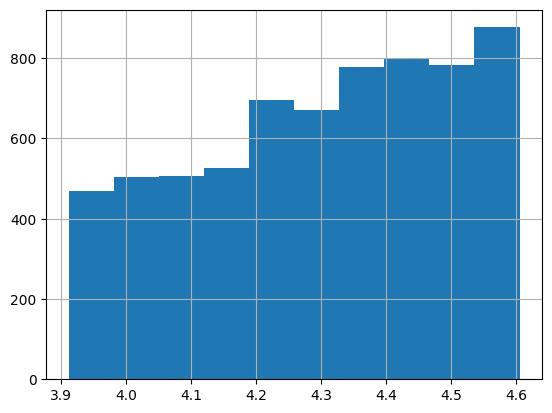

In [ ]:
X_final['Previous_Scores_log'] = np.log(X_final['Previous_Scores'])
X_final['Previous_Scores_log'].hist(bins=10)

In [ ]:
df_experimential.corr()['Exam_Score'].sort_values(ascending=False)

,Exam_Score
Exam_Score,1.000000
Attendance,0.582458
Hours_Studied,0.446514
Previous_Scores,0.174461
Access_to_Resources,0.170936
Parental_Involvement,0.160112
Tutoring_Sessions,0.153754
Peer_Influence,0.099387
Parental_Education_Level_Postgraduate,0.094961
Family_Income,0.092960


## Добавим логарифм от предыдущих результатов

In [ ]:
df_experimential['Previous_Scores_log'] = np.log(df_experimential['Previous_Scores'])
df_experimential.corr()['Exam_Score'].sort_values(ascending=False)

,Exam_Score
Exam_Score,1.000000
Attendance,0.582458
Hours_Studied,0.446514
Previous_Scores,0.174461
Previous_Scores_log,0.172463
Access_to_Resources,0.170936
Parental_Involvement,0.160112
Tutoring_Sessions,0.153754
Peer_Influence,0.099387
Parental_Education_Level_Postgraduate,0.094961


## Что ж, коэффициент корреляции у предыдущих результатов стоит на третьем месте. Как видим, целевой признак имеет довольно хорошую прямую линейную связь с количеством часов сна и посещаемостью

## Разделим данные на обучающие, валидационные и тестовые в пропорции 70:15:15

## Почему нужно именно 3 набора данных? Что ж, довольно часто для моделей надо подбирать параметры для более гибкого обучения и хороших результатов. Дело в том, что модель не должна видеть тестовые данные, иначе она начнет адаптироваться. Так, если мы разделим данные на 2 части и будем сразу на тестовых, а не на валидационных, данных подбирать параметры, модель, скорее всего, переобучится и в конце концов с новыми данными будет работать не столь хорошо. Поэтому лучше забыть о тестовом наборе и вспомнить о нем только во время окончательного тестирования моделей, чтобы не было соблазна подгонять нашу модель под них.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
preprocessing.fit(X_train)
X_train = preprocessing.transform(X_train)
X_valid = preprocessing.transform(X_valid)
X_test = preprocessing.transform(X_test)

## Некоторые модели очень чувствительны к разбросу данных. Поэтому опционально использовать своего рода преобразователи, которые ограничивают значения признаков внутри объектов. Среди наиболее применяемых преобразователей - MinMaxSCaler (получает 2 параметра, по дефолту - (0, 1), внутри которых окажутся все значения), StandardScaler (все данные со средним 1 и стандартным отклонением 0), RobustScaler (все значения между первой и третьей квантилью). Давайте применим StandardScaler к нашим данным

In [ ]:
from sklearn.preprocessing import StandardScaler

stdscaler = StandardScaler()
columns = X_train.columns
X_train_scaled = pd.DataFrame(stdscaler.fit_transform(X_train), columns=stdscaler.get_feature_names_out())
X_valid_scaled = pd.DataFrame(stdscaler.transform(X_valid), columns=stdscaler.get_feature_names_out())
X_test_scaled = pd.DataFrame(stdscaler.transform(X_test), columns=stdscaler.get_feature_names_out())

## Заметьте, что я делаю fit только на тренировочных данных. Это сделано для того, чтобы в дальнейшем не было утечки данных

## Сохраним все для дальнейшего использования

In [ ]:
df_train = pd.concat([X_train_scaled, y_train.reset_index(drop=True)], axis=1)
df_valid= pd.concat([X_valid_scaled, y_valid.reset_index(drop=True)], axis=1)
df_test = pd.concat([X_test_scaled, y_test.reset_index(drop=True)], axis=1)

In [ ]:
df_train.to_csv("data/Train.csv", index=False)
df_valid.to_csv("data/Valid.csv", index=False)
df_test.to_csv("data/Test.csv", index=False)

In [28]:
!git add .

fatal: not a git repository (or any of the parent directories): .git
